=== 1. Binary Classification Test ===
 Accuracies Of Binary Classification 99.50%

=== 2. Multi-class Classification Test ===
 Accuracies Multi-class Classification 92.00%


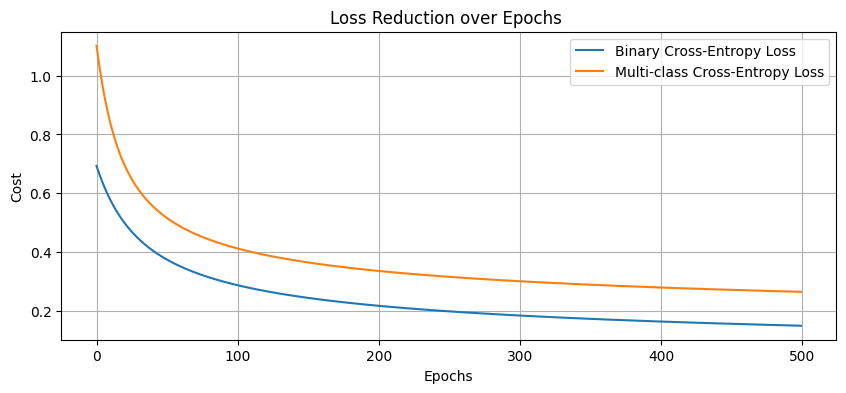

In [6]:

import matplotlib.pyplot as plt
import numpy as np


class FullStackClassifier:
    """
    Full Stack Classifier For Training And Learning
    """

    def __init__(self, mode="binary", learning_rate=0.01, epochs=1000, reg_lambda=0.01):
        self.mode = mode
        self.lr = learning_rate
        self.epochs = epochs
        self.reg_lambda = reg_lambda
        self.W = None
        self.b = None
        self.loss_history = []

    # --- 1. Activation Functions ---
    def _sigmoid(self, z):
        z_clipped = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # --- 2. Initialization ---
    def _initialize_params(self, n_features, n_classes):
        if self.mode == "binary":
            self.W = np.zeros((n_features, 1))
            self.b = 0.0
        elif self.mode == "multiclass":
            self.W = np.random.randn(n_features, n_classes) * 0.01
            self.b = np.zeros((1, n_classes))

    # --- 3. Cost Functions ---
    def compute_cost(self, Y_hat, Y):
        m = Y.shape[0]
        epsilon = 1e-15  
        Y_hat = np.clip(Y_hat, epsilon, 1 - epsilon)

        if self.mode == "binary":
            # Binary Cross-Entropy Cost
            cost = -(1 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
            reg_cost = (self.reg_lambda / (2 * m)) * np.sum(np.square(self.W))
            return cost + reg_cost

        elif self.mode == "multiclass":
            # Categorical Cross-Entropy Cost
            cost = -(1 / m) * np.sum(Y * np.log(Y_hat))
            reg_cost = (self.reg_lambda / (2 * m)) * np.sum(np.square(self.W))
            return cost + reg_cost

    # --- 4. Gradient Descent ---
    def fit(self, X, y):
        m, n_features = X.shape

        if self.mode == "binary":
            Y = y.reshape(-1, 1)
            n_classes = 1
            self._initialize_params(n_features, n_classes)

            for epoch in range(self.epochs):
                # Forward Pass
                Z = np.dot(X, self.W) + self.b
                Y_hat = self._sigmoid(Z)

                # Compute Cost
                cost = self.compute_cost(Y_hat, Y)
                self.loss_history.append(cost)

                # Backward Pass (Gradients)
                dZ = Y_hat - Y
                dW = (1 / m) * np.dot(X.T, dZ) + (self.reg_lambda / m) * self.W
                db = (1 / m) * np.sum(dZ)

                # Update Parameters
                self.W -= self.lr * dW
                self.b -= self.lr * db

        elif self.mode == "multiclass":
            # One-Hot Encoding 
            n_classes = len(np.unique(y))
            Y = np.eye(n_classes)[y]
            self._initialize_params(n_features, n_classes)

            for epoch in range(self.epochs):
                # Forward Pass
                Z = np.dot(X, self.W) + self.b
                Y_hat = self._softmax(Z)

                # Compute Cost
                cost = self.compute_cost(Y_hat, Y)
                self.loss_history.append(cost)

                # Backward Pass (Gradients)
                dZ = Y_hat - Y
                dW = (1 / m) * np.dot(X.T, dZ) + (self.reg_lambda / m) * self.W
                db = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

                # Update Parameters
                self.W -= self.lr * dW
                self.b -= self.lr * db

    # --- 5. Prediction ---
    def predict(self, X):
        if self.mode == "binary":
            Z = np.dot(X, self.W) + self.b
            probabilities = self._sigmoid(Z)
            return (probabilities >= 0.5).astype(int)
        elif self.mode == "multiclass":
            Z = np.dot(X, self.W) + self.b
            probabilities = self._softmax(Z)
            return np.argmax(probabilities, axis=1)



if __name__ == "__main__":
    np.random.seed(42)
    print("=== 1. Binary Classification Test ===")

    # Random Data For Experiment
    X_binary = np.random.randn(200, 2)
    y_binary = (X_binary[:, 0] + X_binary[:, 1] > 0).astype(int)

    clf_binary = FullStackClassifier(mode="binary", learning_rate=0.1, epochs=500)
    clf_binary.fit(X_binary, y_binary)
    preds_b = clf_binary.predict(X_binary).flatten()
    acc_b = np.mean(preds_b == y_binary) * 100
    print(f" Accuracies Of Binary Classification {acc_b:.2f}%")

    print("\n=== 2. Multi-class Classification Test ===")

    X_multi = np.random.randn(300, 2)
    y_multi = np.zeros(300, dtype=int)
    y_multi[X_multi[:, 0] > 0.5] = 1
    y_multi[X_multi[:, 1] < -0.5] = 2

    clf_multi = FullStackClassifier(mode="multiclass", learning_rate=0.1, epochs=500)
    clf_multi.fit(X_multi, y_multi)
    preds_m = clf_multi.predict(X_multi)
    acc_m = np.mean(preds_m == y_multi) * 100
    print(f" Accuracies Multi-class Classification {acc_m:.2f}%")

    plt.figure(figsize=(10, 4))
    plt.plot(clf_binary.loss_history, label="Binary Cross-Entropy Loss")
    plt.plot(clf_multi.loss_history, label="Multi-class Cross-Entropy Loss")
    plt.title("Loss Reduction over Epochs ")
    plt.xlabel("Epochs")
    plt.ylabel("Cost")
    plt.legend()
    plt.grid(True)
  